# Feed Forwad Classification Neural Network

In [43]:
!pip install livelossplot

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import layers, models, optimizers
from livelossplot import PlotLossesKerasTF

## Importing Data

In [45]:
dataset = load_breast_cancer()
display(dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [46]:
data = pd.DataFrame(dataset.data)
display(data)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [47]:
target = pd.Series(dataset.target)
display(target)

,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


## Standardising Data

In [48]:
scalar = StandardScaler()
data_scaled = scalar.fit_transform(data)

## Splitting the Data

In [49]:
X_train, X_test, y_train, y_test = train_test_split(data_scaled, target, test_size=0.2, random_state=42)

## Performing Dimensionality Reduction

In [50]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Light Model

## Training on Data without PCA

In [51]:
lightModel = models.Sequential([
    layers.InputLayer(input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lightModel.compile(
    optimizer=optimizers.Adam(learning_rate=0.002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lightModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

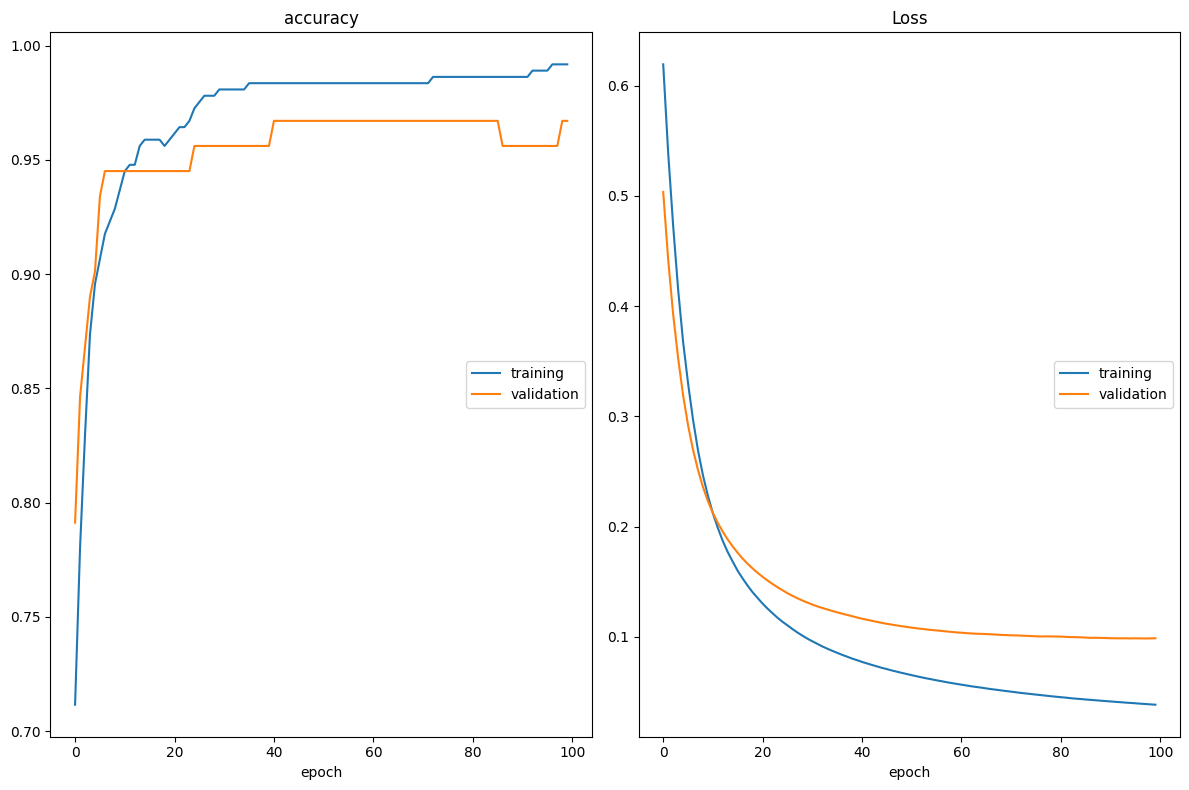

accuracy
	training         	 (min:    0.712, max:    0.992, cur:    0.992)
	validation       	 (min:    0.791, max:    0.967, cur:    0.967)
Loss
	training         	 (min:    0.038, max:    0.619, cur:    0.038)
	validation       	 (min:    0.098, max:    0.504, cur:    0.099)
3/3 - 0s - 142ms/step - accuracy: 0.9918 - loss: 0.0383 - val_accuracy: 0.9670 - val_loss: 0.0986


In [52]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = lightModel.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, PlotLossesKerasTF()],
    verbose=2
)

## Training on Data with PCA

In [53]:
lightModel_pca = models.Sequential([
    layers.InputLayer(input_shape=(X_train_pca.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

lightModel_pca.compile(
    optimizer=optimizers.Adam(learning_rate=0.002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lightModel_pca.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

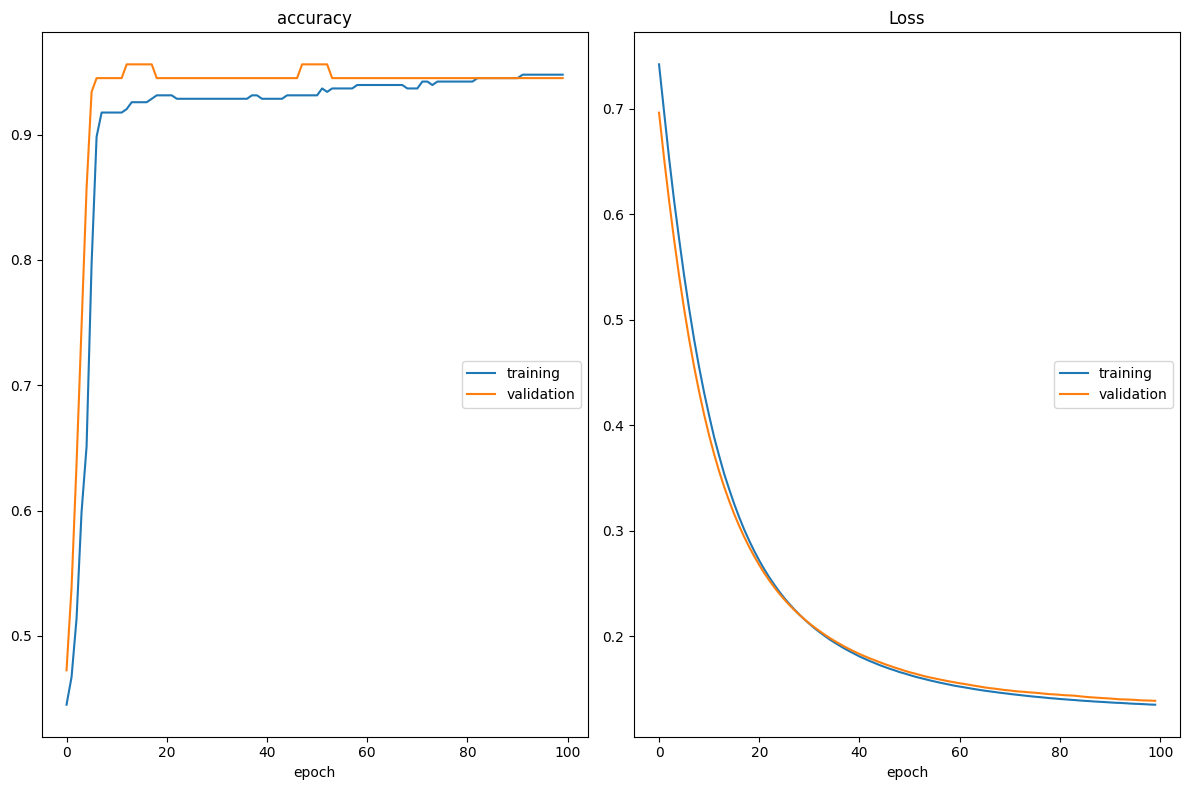

accuracy
	training         	 (min:    0.445, max:    0.948, cur:    0.948)
	validation       	 (min:    0.473, max:    0.956, cur:    0.945)
Loss
	training         	 (min:    0.135, max:    0.742, cur:    0.135)
	validation       	 (min:    0.139, max:    0.696, cur:    0.139)
3/3 - 0s - 142ms/step - accuracy: 0.9478 - loss: 0.1353 - val_accuracy: 0.9451 - val_loss: 0.1390


In [54]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = lightModel_pca.fit(
    X_train_pca, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, PlotLossesKerasTF()],
    verbose=2
)

## Light Model Evaluation

In [55]:
light_y_pred = lightModel.predict(X_test)
light_y_pred_pca = lightModel_pca.predict(X_test_pca)

print("Classification Report (Original Features):")
print(classification_report(y_test, (light_y_pred > 0.5).astype(int)))
print("Confusion Matrix (Original Features):")
print(confusion_matrix(y_test, (light_y_pred > 0.5).astype(int)),"\n")

print("Classification Report (PCA Features):")
print(classification_report(y_test, (light_y_pred_pca > 0.5).astype(int)))
print("Confusion Matrix (PCA Features):")
print(confusion_matrix(y_test, (light_y_pred_pca > 0.5).astype(int)))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Classification Report (Original Features):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix (Original Features):
[[42  1]
 [ 1 70]] 

Classification Report (PCA Features):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

Confusion Matrix (PCA Features):
[[42  1]
 [ 0 71]]


# Deep Model

## Training on Data without PCA

In [56]:
deepModel = models.Sequential([
    layers.InputLayer(input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

deepModel.compile(
    optimizer=optimizers.Adam(learning_rate=0.002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deepModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)

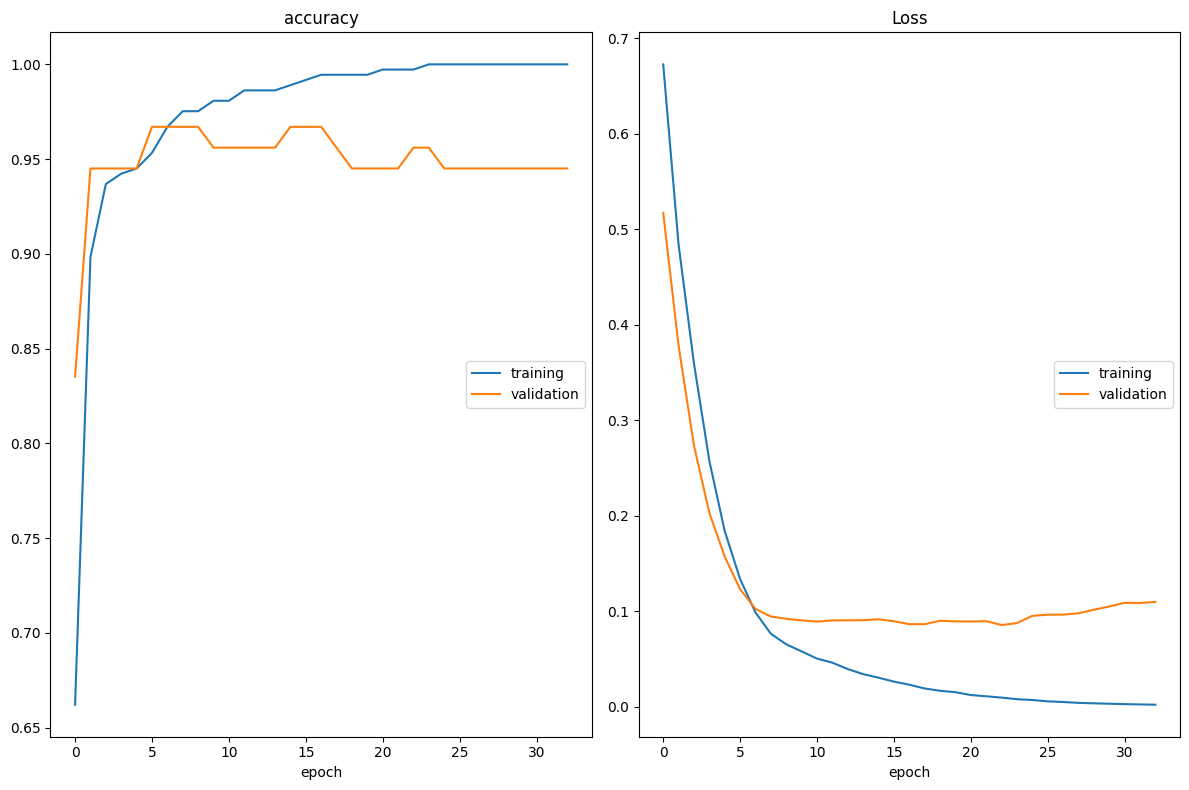

accuracy
	training         	 (min:    0.662, max:    1.000, cur:    1.000)
	validation       	 (min:    0.835, max:    0.967, cur:    0.945)
Loss
	training         	 (min:    0.002, max:    0.673, cur:    0.002)
	validation       	 (min:    0.085, max:    0.517, cur:    0.110)
3/3 - 1s - 331ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9451 - val_loss: 0.1097


In [57]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = deepModel.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, PlotLossesKerasTF()],
    verbose=2
)

## Training on Data with PCA

In [58]:
deepModel_pca = models.Sequential([
    layers.InputLayer(input_shape=(X_train_pca.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

deepModel_pca.compile(
    optimizer=optimizers.Adam(learning_rate=0.002),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

deepModel_pca.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

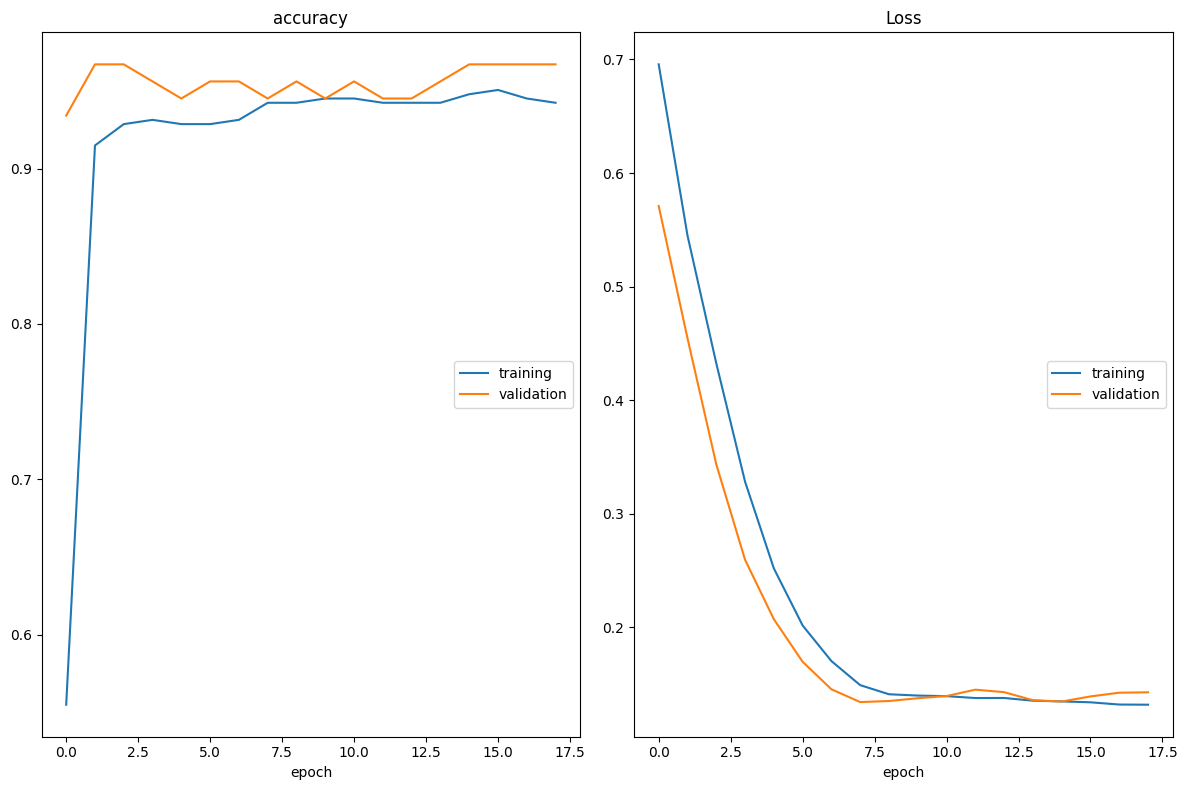

accuracy
	training         	 (min:    0.555, max:    0.951, cur:    0.942)
	validation       	 (min:    0.934, max:    0.967, cur:    0.967)
Loss
	training         	 (min:    0.132, max:    0.696, cur:    0.132)
	validation       	 (min:    0.134, max:    0.571, cur:    0.143)
3/3 - 1s - 224ms/step - accuracy: 0.9423 - loss: 0.1320 - val_accuracy: 0.9670 - val_loss: 0.1429


In [59]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = deepModel_pca.fit(
    X_train_pca, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[early_stopping, PlotLossesKerasTF()],
    verbose=2
)

## Deep Model Evaluation

In [60]:
deep_y_pred = deepModel.predict(X_test)
deep_y_pred_pca = deepModel_pca.predict(X_test_pca)

print("Classification Report (Original Features):")
print(classification_report(y_test, (deep_y_pred > 0.5).astype(int)))
print("Confusion Matrix (Original Features):")
print(confusion_matrix(y_test, (deep_y_pred > 0.5).astype(int)),"\n")

print("Classification Report (PCA Features):")
print(classification_report(y_test, (deep_y_pred_pca > 0.5).astype(int)))
print("Confusion Matrix (PCA Features):")
print(confusion_matrix(y_test, (deep_y_pred_pca > 0.5).astype(int)))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Classification Report (Original Features):
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix (Original Features):
[[41  2]
 [ 1 70]] 

Classification Report (PCA Features):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114

Confusion Matrix (PCA Features):
[[42  1]
 [ 0 71]]


# All Model Comaprison

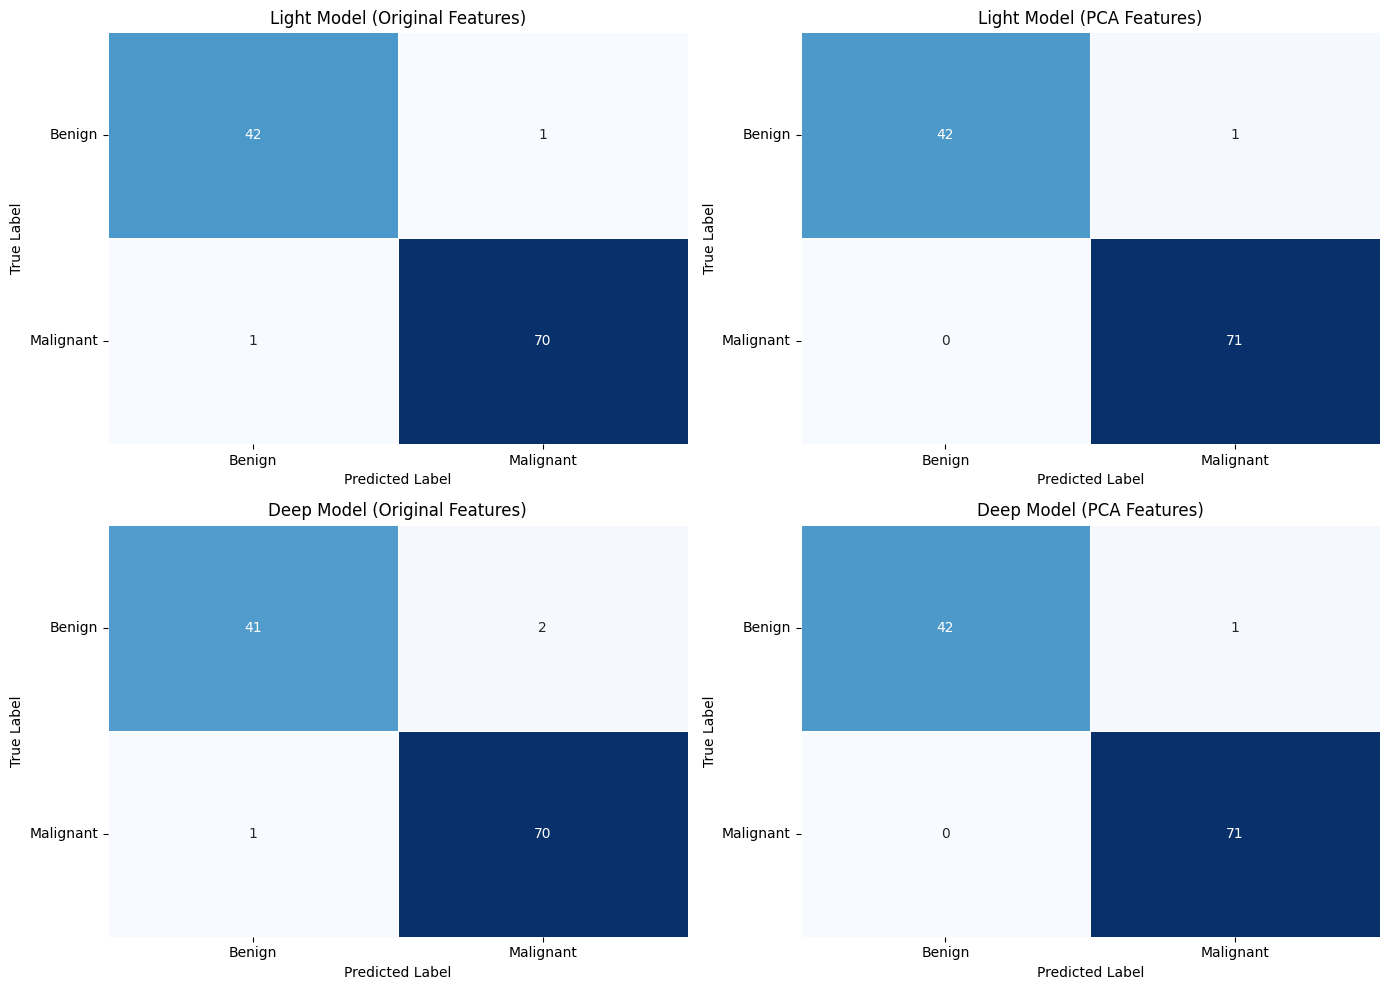

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_results = [
    ("Light Model (Original Features)", light_y_pred),
    ("Light Model (PCA Features)", light_y_pred_pca),
    ("Deep Model (Original Features)", deep_y_pred),
    ("Deep Model (PCA Features)", deep_y_pred_pca),
]

for ax, (title, preds) in zip(axes, model_results):
    cm = confusion_matrix(y_test, (preds > 0.5).astype(int))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        linewidths=0.5,
        linecolor='white'
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_yticklabels(['Benign', 'Malignant'], rotation=0)

plt.tight_layout()
plt.show()

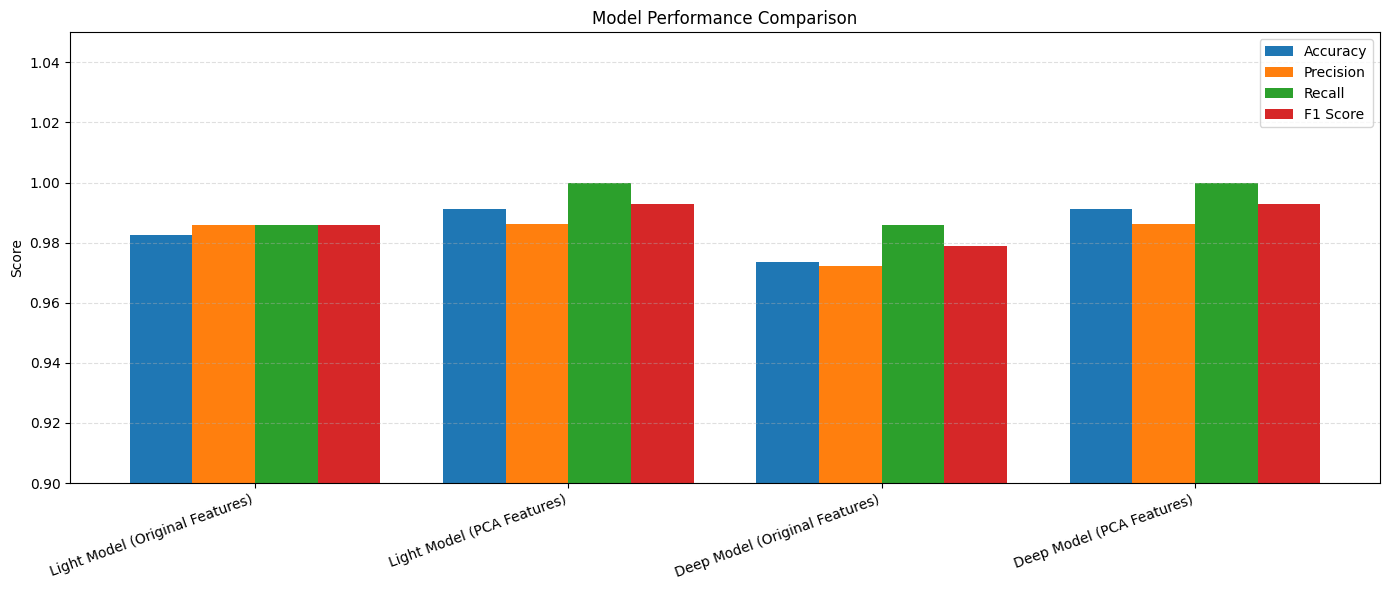

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_names = [
    'Light Model (Original Features)',
    'Light Model (PCA Features)',
    'Deep Model (Original Features)',
    'Deep Model (PCA Features)'
]

predictions = [
    (light_y_pred > 0.5).astype(int),
    (light_y_pred_pca > 0.5).astype(int),
    (deep_y_pred > 0.5).astype(int),
    (deep_y_pred_pca > 0.5).astype(int),
]

metrics = {
    'Accuracy': [accuracy_score(y_test, pred) for pred in predictions],
    'Precision': [precision_score(y_test, pred) for pred in predictions],
    'Recall': [recall_score(y_test, pred) for pred in predictions],
    'F1 Score': [f1_score(y_test, pred) for pred in predictions],
}

plt.figure(figsize=(14, 6))
ax = plt.gca()

x = np.arange(len(model_names))
width = 0.2

for i, (metric_name, values) in enumerate(metrics.items()):
    ax.bar(x + (i - 1.5) * width, values, width=width, label=metric_name)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_ylim(0.9, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()